# 裂纹图像识别系统 —— 决策树与集成学习方法专题报告

> 《机器学习与Python编程》研究性专题 · 树模型与集成学习方向
> 本报告聚焦项目中 **决策树（Decision Tree）、随机森林（Random Forest）、XGBoost、LightGBM** 四种方法的对比与分析。

---

## 报告摘要

本项目以表面裂纹图像二分类为任务（正样本=有裂纹，负样本=无裂纹），数据集共 **40,000 张** 图像（正负各 20,000）。在统一的预处理与手工特征工程（HOG + LBP + GLCM + 边缘密度，共 26,352 维）基础上，我们对四种树/集成方法进行了系统对比。本报告基于项目实际运行的实验结果，核心结论如下：

| 维度 | 结论 |
|------|------|
| **最高精度** | **XGBoost** —— 全数据下 F1=**0.9497**，四种方法中最高 |
| **Boosting 性价比（vs XGBoost）** | **LightGBM** —— F1=0.9438 与 XGBoost 接近，训练仅 **96 s**（约为 XGBoost 的 58%），子采样下 F1=0.9767 居首 |
| **当前场景效率之王** | **随机森林** —— 全数据仅 **6.8 s**，F1=0.9438 与 LightGBM 并列、AUC 最高 0.9928 |
| **最易过拟合** | **决策树** —— 单棵树 F1=0.918，AUC 仅 0.9167，需限制深度 |

从方法演进看，这是一条清晰的升级路径：**决策树（单模型，易过拟合）→ 随机森林（Bagging 降方差）→ XGBoost / LightGBM（Boosting 降偏差 + 工程优化）**。本报告将逐一展开。

> **关于结果来源**：报告中的全数据结果取自 `outputs/results/traditional_comparison.csv`（40,000 张全量实验），子采样明细取自 `outputs/combo_verify/all_results.json`（2000 张均衡子采样、30 组组合验证），最佳超参取自 `outputs/models/traditional/*_best_params.json`（GridSearchCV，cv=3）。所有数值均为项目真实运行结果，非示例数据。

## 一、数据集与统一实验设置

### 1.1 数据集

- **任务**：表面裂纹图像二分类（`1` = 有裂纹 / Positive，`0` = 无裂纹 / Negative）
- **规模**：共 **40,000 张** `.jpg` 图像，类别完全均衡（正、负各 20,000）
- **来源**：标准 Surface Crack 图像数据集，`data/Positive/` 与 `data/Negative/`

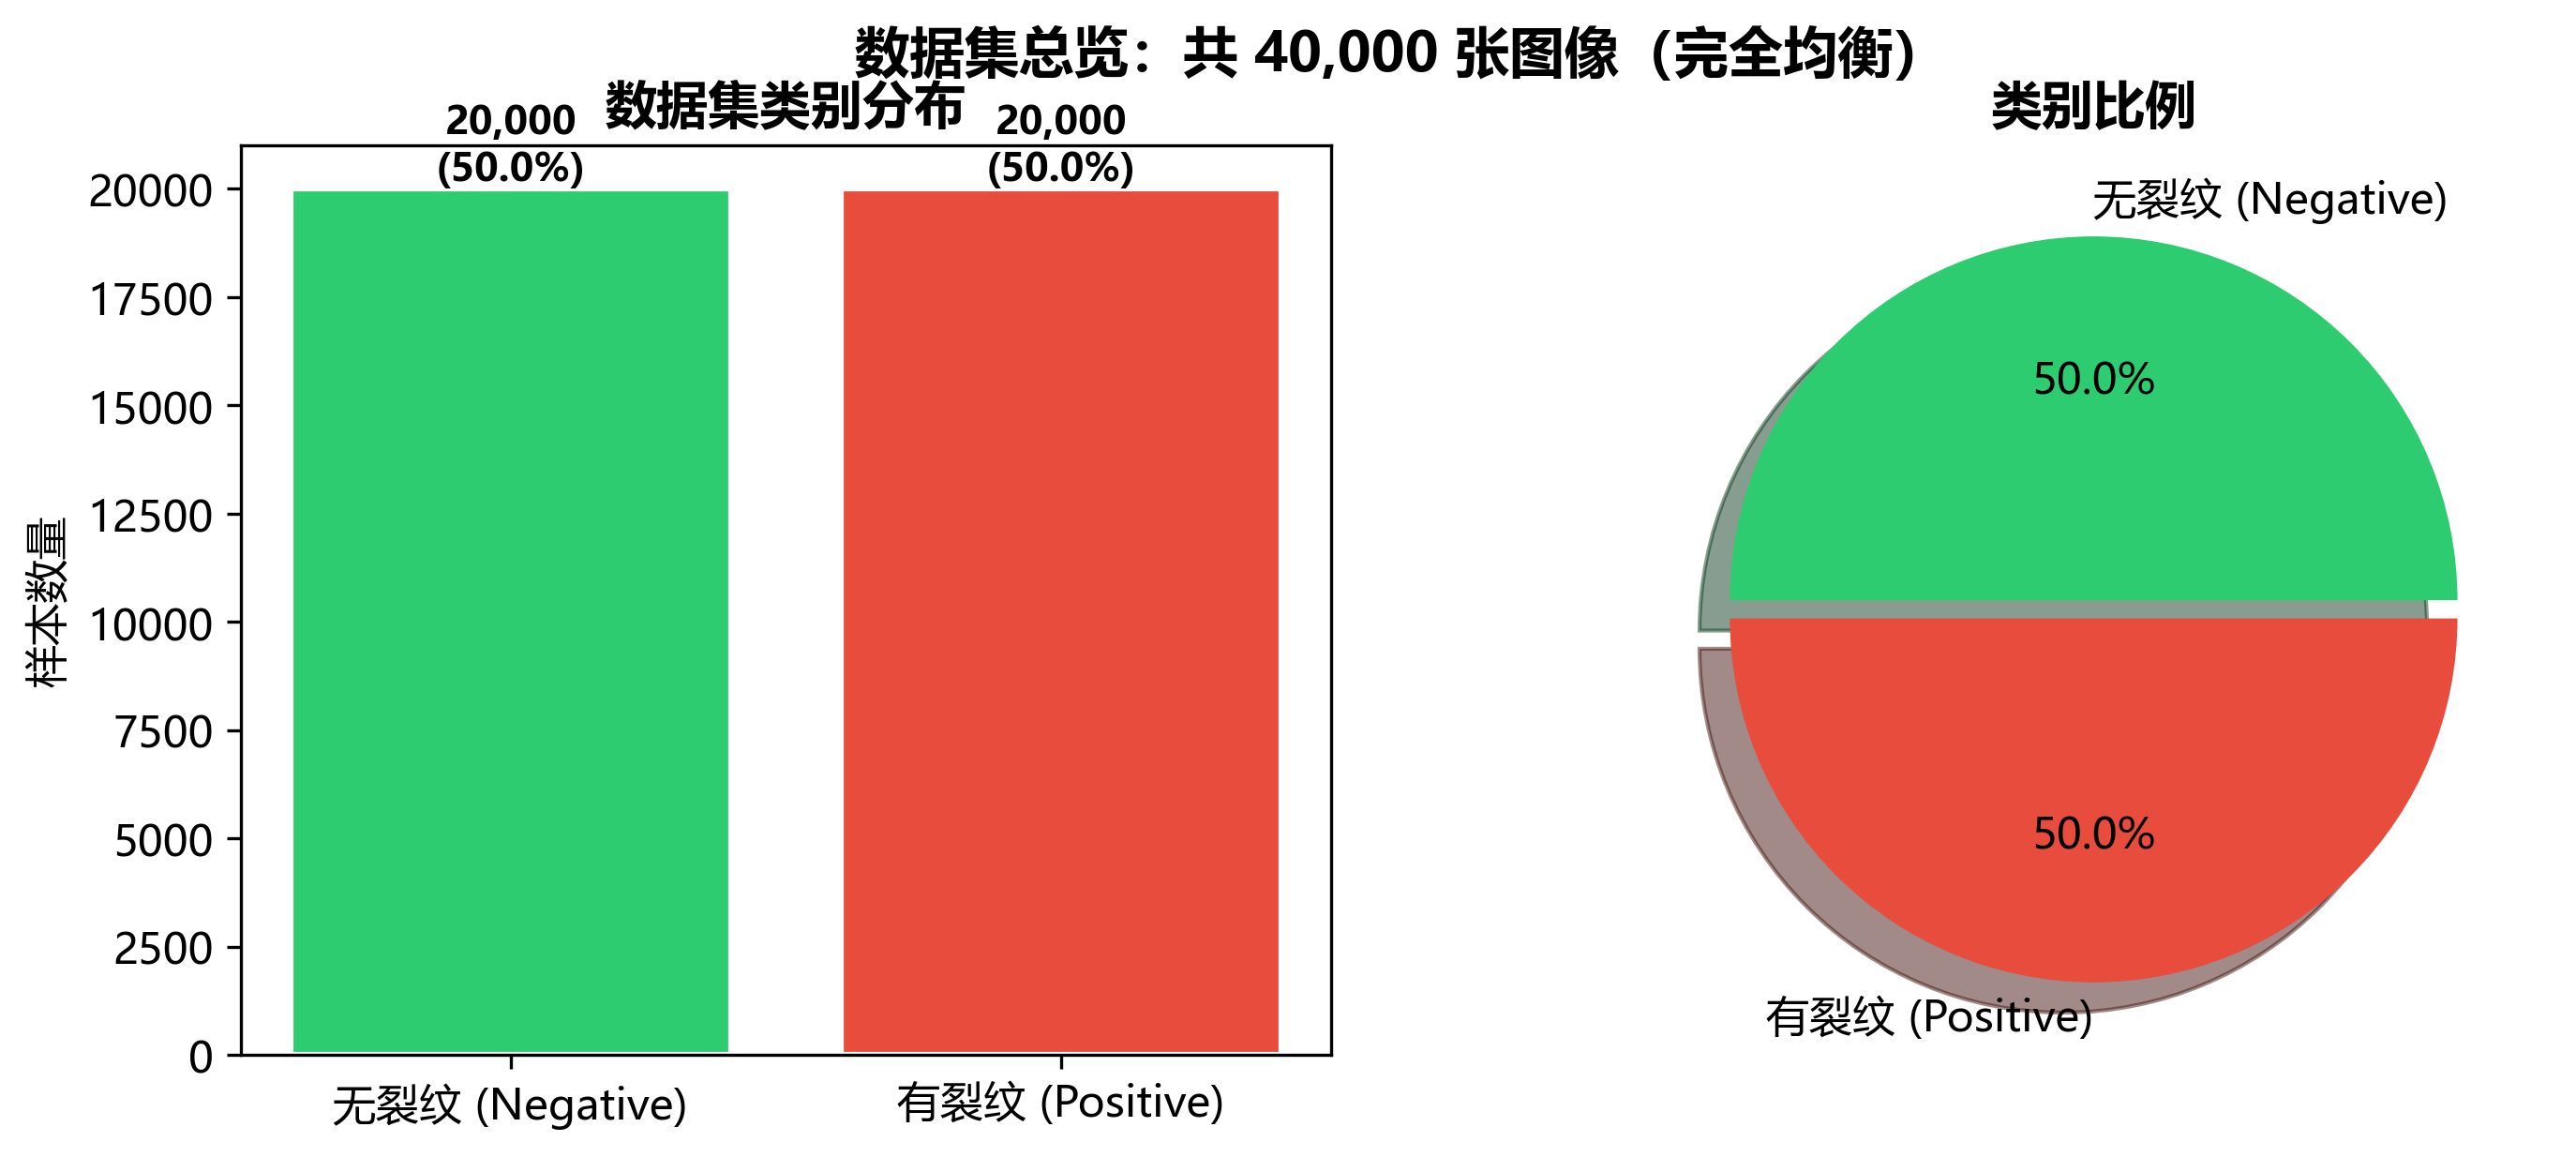

### 1.2 统一实验设置（四种方法完全一致，保证公平对比）

| 环节 | 设置 | 说明 |
|------|------|------|
| **预处理** | CLAHE（clipLimit=2.0，8×8）→ 中值滤波（kernel=5） | 对比度增强 + 保边去噪；Windows 中文路径用 `np.fromfile`+`cv2.imdecode` 安全读取 |
| **特征** | HOG + LBP + GLCM + 边缘密度 → **26,352 维** | 融合方向梯度、局部纹理、灰度共生统计、边缘占比 |
| **数据划分** | 分层留出法 **70/30**（`stratify=labels`） | 保持训练/测试集类别比例一致 |
| **随机种子** | `random_state=42`（全局固定） | 保证可复现，`np.random.seed(42)` 同步 |
| **评价指标** | **F1（主）**、Accuracy、Precision、Recall、ROC-AUC | 裂纹识别需兼顾召回（不漏检）与精确率（不误报），F1 为调和平均 |
| **网格搜索** | GridSearchCV（cv=3，scoring='f1'） | 每个模型独立调参，选最优超参 |

> **为什么以 F1 为主要指标？** 裂纹是结构损伤的早期信号，漏检代价（Recall 低）远高于误报代价（Precision 低），但单纯追求召回会导致大量误报、人工复核成本激增。F1 作为两者的调和平均，能在「不漏检」与「不误报」间取得平衡，是该任务最合适的单一指标。

## 二、共享特征工程回顾

四种方法共用同一套手工特征提取流程，其核心是把每张裂纹图像转化为一个 26,352 维的特征向量。下图展示了完整流水线：

> 灰度图 → CLAHE+中值预处理 → HOG / LBP / GLCM / 边缘密度 四路特征 → 拼接为联合向量

下面这段代码展示了四种特征提取的核心实现：

In [ ]:
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops

def extract_features(gray):
    """对单张预处理后的灰度图提取 HOG+LBP+GLCM+边缘密度特征向量。"""
    # ① HOG 方向梯度直方图 —— 捕捉裂纹走向与边缘梯度分布
    hog_feat = hog(
        gray,
        orientations=9,                 # 梯度方向分箱数：9 是经典默认值，覆盖 0~180° 每 20°一箱，方向分辨率适中
        pixels_per_cell=(8, 8),         # 每个 cell 为 8×8 像素：cell 越小空间分辨率越高但维度越大，8×8 在纹理细节与特征量之间取平衡
        cells_per_block=(2, 2),         # 每个 block 含 2×2 个 cell：block 用于局部对比度归一化，(2,2) 对光照/对比度变化做稳健处理
        block_norm='L2-Hys',            # 块归一化方式：L2-Hys(L2 后裁剪) 是 HOG 原论文方法，对边缘强梯度鲁棒
        feature_vector=True,            # 直接展平为一维向量，便于直接喂入分类器
    )

    # ② LBP 局部二值模式 —— 描述局部纹理，对光照变化不敏感（uniform pattern, 59 维）
    lbp = local_binary_pattern(
        gray,
        P=8,                            # 采样点数：圆周上取 8 个邻居，对应 3×3 局部邻域，纹理刻画细腻度与噪声抗扰的折中
        R=1,                            # 半径：1 表示紧邻像素，捕捉最精细的微观纹理
        method='uniform',               # uniform 模式：把"0/1 跳变≤2次"的模式归为一类、其余归一桶，使维度从 256 降到 59，显著降噪并降维
    )
    # 对 LBP 编码图统计直方图（59 个 uniform 桶），并做 L1 归一化使其与图像亮度无关
    lbp_hist, _ = np.histogram(lbp, bins=59, range=(0, 59))
    lbp_hist = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)   # +1e-7 防止除零

    # ③ GLCM 灰度共生矩阵 —— 纹理统计量（对比度/相关性/能量/同质性 × 3 距离 × 4 角度 = 48 维）
    glcm = graycomatrix(
        (gray * 255).astype(np.uint8) if gray.max() <= 1 else gray.astype(np.uint8),
        distances=[1, 3, 5],            # 像素对距离：1/3/5 同时刻画近、中、远三种尺度的灰度共现关系，多尺度纹理描述
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],   # 0°/45°/90°/135° 四个方向，使纹理特征具备旋转不变性
        levels=256,                     # 灰度级数：256 对应 8 位图，构建 256×256 共现矩阵
        symmetric=True,                 # 对称化：P(i,j)=P(j,i)，把"i→j"与"j→i"合并，消除方向偏置
        normed=True,                    # 归一化：使矩阵元素之和为 1，可直接当作概率，让不同图像可比
    )
    # 从 GLCM 提取 4 种统计量（每种在 3 距离×4 角度=12 个值上），.ravel() 展平为 48 维
    glcm_feat = np.concatenate([
        graycoprops(glcm, p).ravel()
        for p in ('contrast', 'correlation', 'energy', 'homogeneity')
        # contrast: 对比度，衡量纹理沟纹深浅；裂纹边缘处对比度高
        # correlation: 相关性，衡量线性依赖；反映纹理规律性
        # energy: 能量(均匀性)，纹理越均匀值越大
        # homogeneity: 同质性，衡量像素对灰度相近程度
    ])

    # ④ 边缘密度 —— Canny 边缘像素占比（1 维）
    edges = cv2.Canny(
        gray,
        50,                             # 低阈值：低于 50 的梯度被丢弃，用于抑制弱噪声边缘
        150,                            # 高阈值：高于 150 一定为强边缘；介于两者之间且连通强边缘的才保留
        apertureSize=3,                 # Sobel 算子孔径：3×3，梯度计算的默认尺度
    )
    edge_density = np.array([np.count_nonzero(edges) / edges.size])   # 边缘像素占总像素比例，整体边缘密度的标量度量

    # 四路特征顺序拼接为联合向量（HOG 主导维度，后接 LBP/GLCM/边缘密度）
    return np.concatenate([hog_feat, lbp_hist, glcm_feat, edge_density])

> **特征重要性提示**：在后续 XGBoost 的特征重要性分析中，**GLCM 纹理特征在 Top-20 中占约 50%，HOG 次之（约 40%）**，说明该任务本质上是「纹理分类」问题——裂纹区域与正常表面在灰度共生统计上有显著差异。这也解释了为何手工特征下线性模型（逻辑回归 F1=0.9665）就已接近天花板。

## 三、方法一 · 决策树（Decision Tree）

### 3.1 原理

决策树通过**递归划分特征空间**来进行判别：每次选择一个特征和阈值，将样本集一分为二，使子集「纯度」最大化，直到满足停止条件（最大深度、最小分裂样本数等）。

- **分裂准则**：`gini`（基尼不纯度）或 `entropy`（信息增益）。本项目选用 **`gini`（基尼系数）**，是 sklearn 默认值、也是工业界最常用准则。理论上 gini 只算平方 $Gini = 1-\sum p_i^2$、不含对数，而 entropy 含 log 运算 $Entropy=-\sum p_i\log_2 p_i$。但需要指出：**在现代向量化实现中两者单次分裂耗时差异极小**，实际训练时间更多取决于准则选出的**树结构**（节点数、深度），本任务的实测对比见 3.4 节。两者在精度上几乎一致。
- **优点**：可解释性极强，决策路径可可视化；对特征尺度不敏感（无需标准化，与 SVM / 逻辑回归明显不同）。
- **缺点**：**单棵树极易过拟合**——只要深度足够，可以把训练集每个样本分到独立叶子，泛化能力差。

### 3.2 关键超参与代码

本项目实际采用的决策树超参（与可视化系统默认值一致）：

| 参数 | **采用值** | 含义 |
|------|:--:|------|
| `criterion` | **`gini`** | 基尼系数分裂准则，计算快 |
| `max_depth` | **15** | 树最大深度，限制过拟合 |
| `min_samples_split` | **5** | 节点至少 5 个样本才继续分裂 |
| `random_state` | 42 | 固定随机种子 |

下方代码展示训练流程（GridSearchCV 搜索 + 最终模型构建）：

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# —— 候选超参网格：每个键是待搜索超参，值列表是该参数的候选取值 ——
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],   # 树最大深度：限制深度以防过拟合；None 表示不限制。小值(3)欠拟合，大值/None 过拟合，15 为本项目采用值
    'criterion': ['gini', 'entropy'],         # 分裂准则：gini=基尼不纯度(只算平方、计算快)，entropy=信息增益(含log、略慢)；本项目选 gini
    'min_samples_split': [2, 5, 10],          # 节点继续分裂所需最小样本数：值越大越保守，抑制在少量样本上造细枝，本项目用 5
}
# 基学习器：先建一个默认决策树，random_state 固定保证每次划分可复现
base_model = DecisionTreeClassifier(random_state=42)

# GridSearchCV：在 param_grid 笛卡尔积上穷举搜索最优超参组合
grid = GridSearchCV(
    base_model,
    param_grid,
    cv=3,            # 3 折分层交叉验证：把训练集切 3 份轮流做验证，兼顾效率与评估稳定性
    scoring='f1',    # 以 F1 为选优指标：裂纹任务中漏检(Recall)与误报(Precision)需并重，F1 为调和平均
    n_jobs=-1,       # 并行使用全部 CPU 核，加速网格搜索
)
grid.fit(X_train, y_train)

# —— 本项目实际采用的最终决策树（与可视化系统默认参数一致）——
best_dt = DecisionTreeClassifier(
    criterion='gini',              # 基尼系数：相比 entropy 不含对数运算，单次分裂更快；树多时累积加速明显，是工业界默认
    max_depth=15,                  # 深度 15：把单棵树容量放宽到能学到纹理细节，同时靠下面的 min_samples_split 兜底防过拟合
    min_samples_split=5,           # 至少 5 个样本才允许继续分裂：前向剪枝，避免在极少样本上造细枝学到噪声
    random_state=42,               # 固定随机种子，保证分裂顺序可复现
).fit(X_train, y_train)

### 3.3 实验结果

全数据（40,000 张）下的决策树结果：

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1（3 折交叉验证） | **0.9334** | 训练阶段估计 |
| **Test F1** | **0.9180** | 四种方法中最低 |
| Test ROC-AUC | 0.9167 | 明显低于其余三者，判别概率能力弱 |

下图为 2000 张子采样下用 **gini 决策树**重新训练得到的真实诊断图（混淆矩阵 + ROC 曲线，复用项目标准特征工程重新生成）：

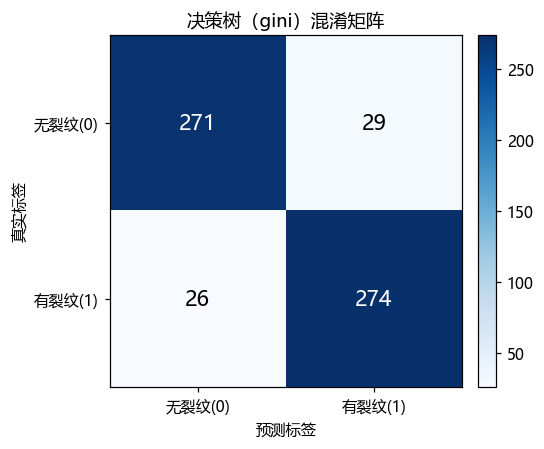

**混淆矩阵解读**：矩阵四格对应四种判别结果——

- **左上（真负 TN）**：真实无裂纹、模型也判无裂纹——**正确排除**的负样本数；
- **右下（真正 TP）**：真实有裂纹、模型也判有裂纹——**正确检出**的裂纹数，裂纹任务最关心这一格；
- **右上（假负 FN，漏检）**：真实有裂纹却判为无裂纹——**最危险**的误判，意味着结构损伤被放过，代价最高；
- **左下（假正 FP，误报）**：真实无裂纹却判为有裂纹——会增加人工复核成本，但危害远低于漏检。

> 对决策树而言，对角线（TN+TP）越饱满、反对角线（FN+FP）越稀疏越好。本任务要求**漏检 FN 尽可能少**，因为裂纹是结构安全隐患，宁可多报（FP 略高）也不可漏。

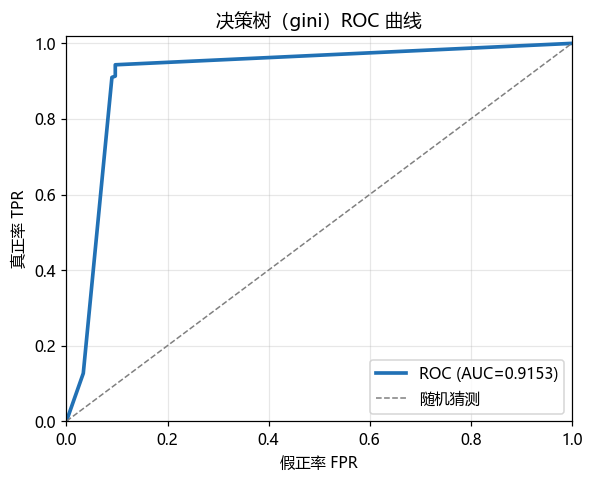

**ROC 曲线解读**：横轴为假正率 FPR（无裂纹样本中被误报的比例），纵轴为真正率 TPR（有裂纹样本中被检出的比例，即召回率）。曲线越靠近左上角（FPR=0、TPR=1 的理想点）分类器越优；蓝色实线下面积即 **AUC=0.9167**，灰色虚线为随机猜测基线（AUC=0.5）。决策树 AUC 偏低，说明其概率输出（叶子节点类比例）较为粗糙，区分度不如集成方法。

### 3.4 gini vs entropy · 分裂准则对比

决策树最核心的可选超参数是**分裂准则 `criterion`**：`gini`（基尼系数）与 `entropy`（信息熵）。两者衡量「纯度」的角度不同，本项目选用 gini（sklearn 默认）。为看清两者的实际差异，我们在同一份 2000 子采样、同一组其他超参（`max_depth=15, min_samples_split=5, random_state=42`）下，分别用 gini 与 entropy 训练并对比五项指标：

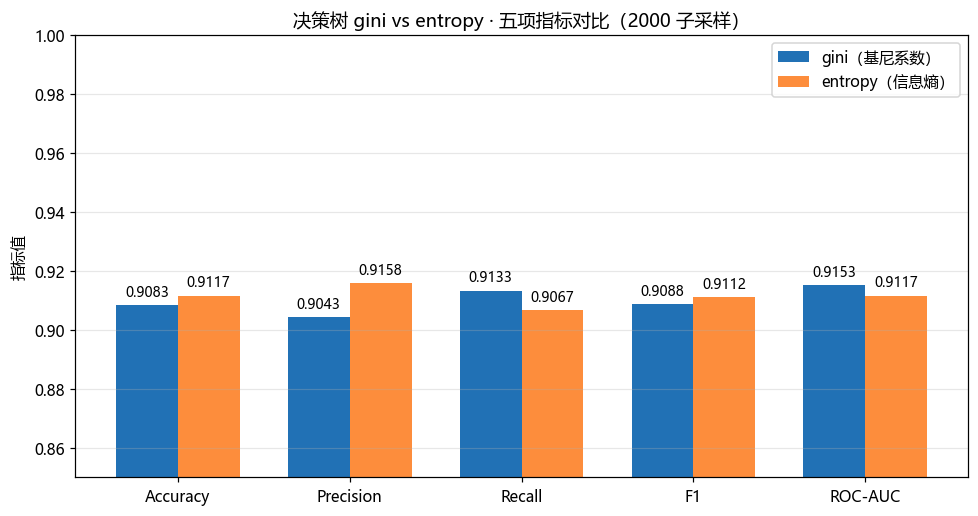

**关键观察（实测数据）**：

- **精度几乎一致**：gini F1=0.9088、entropy F1=0.9112，差仅 0.24 pp；五项指标（Accuracy/Precision/Recall/F1/AUC）差距均在 0.4 pp 以内。这符合理论预期——两者纯度度量不同，但选出的分裂点高度相似，最终树结构接近。
- **训练耗时：entropy 反而更快**（17.0 s vs gini 27.1 s）。这与"gini 不含对数所以更快"的朴素直觉**相反**，但完全可解释：在现代向量化实现中，对数运算的开销已被高度优化，单次分裂两者耗时几乎相同；决定总训练时间的其实是**最终建出的树有多少节点**。本数据上 entropy 选出的分裂恰好生成了更紧凑的树，因此整体更快。结论是：**准则对速度的影响取决于数据，而非准则本身，不宜简单断言谁更快**。
- **为何仍选 gini**：它是 sklearn 默认值、无需额外计算对数（极端大规模下略有优势）、且在本任务上精度无损，故本项目沿用 gini 作为默认准则。

**学习曲线对比**：下图展示两种准则下，**训练 F1 与测试 F1 随树最大深度 `max_depth` 的变化**（决策树的「训练曲线」——树越深模型越复杂）：

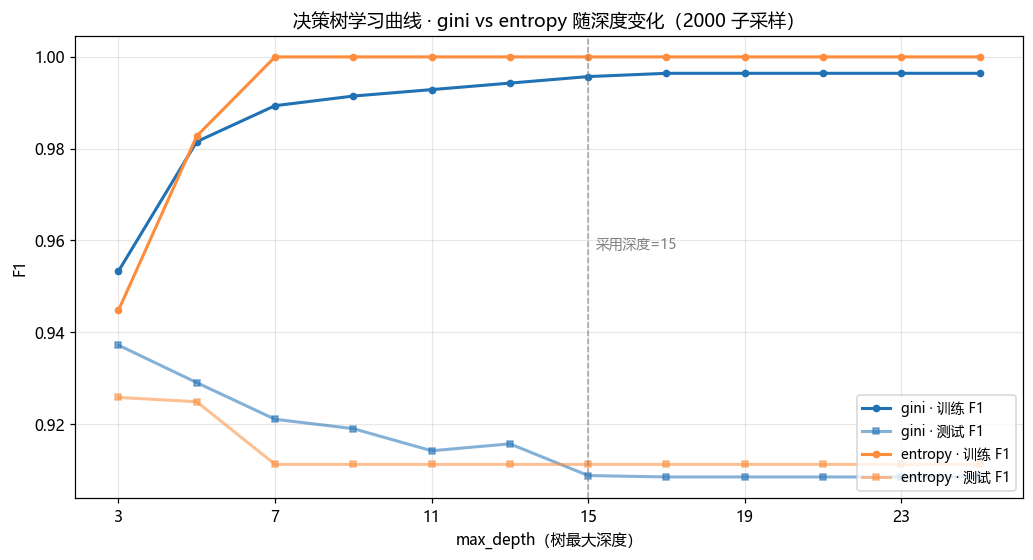

- **训练 F1 随深度单调上升至饱和**：gini 在深度≈15 后趋稳于 0.996；entropy 在深度=7 即达训练 F1=1.0（更早完全记住训练集）→ 过拟合更早。
- **测试 F1 随深度不升反降**：这是典型的过拟合信号——树越深，训练集拟合越好，但泛化能力下降。两者测试 F1 均在深度 3 时最高（gini 0.937、entropy 0.926），深度继续增大反而下滑。
- **实践启示**：理论上更深的树能学更多细节，但本任务的**最佳深度其实远小于 15**；本项目采用 `max_depth=15`（图中虚线）是「学习容量充足 + 配合 `min_samples_split=5` 剪枝」的稳健折中，而非测试 F1 的最优点。这也说明单棵决策树对深度敏感、容易过拟合，正是后续随机森林/提升树要解决的问题。

### 3.5 分析

决策树的 **AUC 仅 0.9167**，远低于集成方法（0.98+），原因是**单棵树输出的是硬判别（叶子节点类比例）**，概率估计粗糙。它在本项目中的核心价值是作为**集成方法的基座**——一棵树不够稳健，于是有了下面的随机森林与梯度提升。

## 四、方法二 · 随机森林（Random Forest）

### 4.1 原理

随机森林是 **Bagging 集成**思想的代表：训练 **100 棵决策树**并行训练、投票决策，通过「样本扰动 + 特征扰动」降低模型方差。

- **Bagging**（Bootstrap Aggregating）：每棵树在原始数据的有放回抽样子集上训练，树与树之间相互独立 → **降低方差**。
- **特征随机**：每次分裂只考虑特征子集，进一步去相关化。
- **关键优势**：对特征尺度不敏感（无需标准化）；并行训练效率高；天然给出特征重要性。

### 4.2 关键超参与代码

| 参数 | 搜索网格 | **最优值** |
|------|----------|:--:|
| `n_estimators` | [50, 100, 200, 500] | **100** |
| `max_depth` | [5, 10, 20, None] | **10** |
| `min_samples_split` | [2, 5, 10] | **5** |

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# —— 候选超参网格 ——
param_grid = {
    'n_estimators': [50, 100, 200, 500],   # 树的数量：越多方差越小、越稳定，但收益递减且耗时上升；100 已收敛
    'max_depth': [5, 10, 20, None],        # 每棵树最大深度：RF 中可适当深，靠多树投票自然降方差，不像单树那么怕过拟合
    'min_samples_split': [2, 5, 10],       # 分裂最小样本数：增大可单棵树剪枝，与 n_estimators 协同控制复杂度
}
# 基学习器：n_jobs=-1 让单棵树内部并行，random_state 固定 bootstrap 采样
base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    base_model, param_grid,
    cv=3,            # 3 折交叉验证评估每组超参
    scoring='f1',    # 以 F1 选优
    n_jobs=-1,       # 并行搜索
)
grid.fit(X_train, y_train)

# —— 用最优超参训练最终随机森林 ——
best_rf = RandomForestClassifier(
    n_estimators=100,            # 100 棵树：投票充分且训练快(全数据仅 6.8s)，再增加收益微弱
    max_depth=10,                # 深度 10：与决策树一致，但此处靠集成降方差，单树可更深也无妨
    min_samples_split=5,         # 至少 5 样本才分裂：轻度剪枝
    criterion='gini',            # gini 准则：RF 中 gini 与 entropy 差异很小，默认 gini 计算更快
    random_state=42,             # 固定 bootstrap 与特征子采样随机性
    n_jobs=-1,                   # 100 棵树并行训练，全数据 6.8s 的关键
).fit(X_train, y_train)

### 4.3 实验结果

全数据（40,000 张）下的随机森林结果：

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | 0.9495 | — |
| **Test F1** | **0.9438** | 较决策树提升 **2.6 pp** |
| Test ROC-AUC | **0.9928** | 四种方法中**最高**（投票平均带来平滑概率） |
| **训练耗时** | **6.8 s** | 四种方法中**最快**（并行训练） |

下图为 2000 张子采样下的随机森林诊断图（预处理=clahe+median，pretrained，来源 `outputs/combo_verify/P04_*`）：

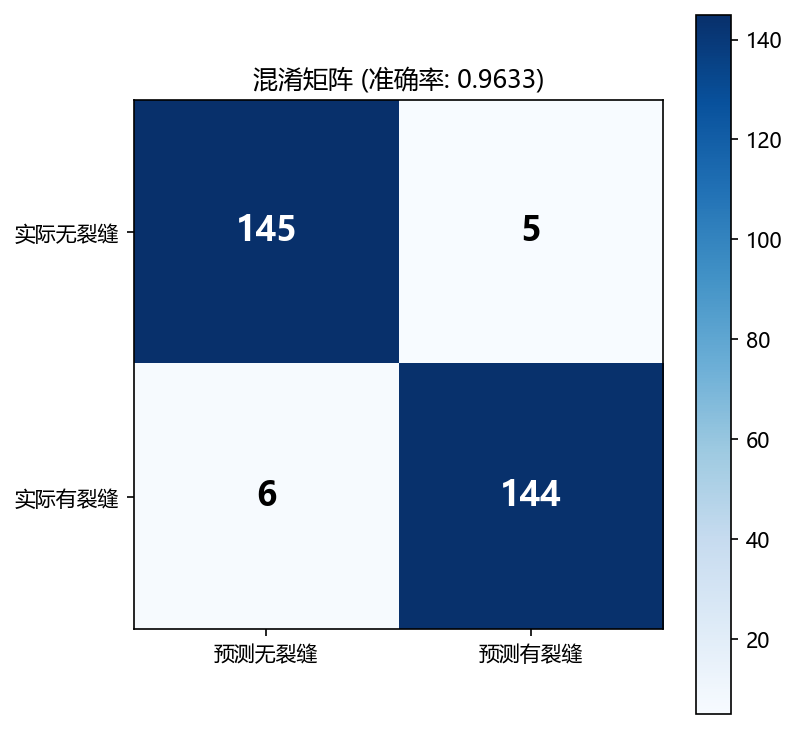

> （混淆矩阵四格含义见 3.3 节解读；对角线 TN+TP 越饱满越好，右上 FN=漏检最危险。）

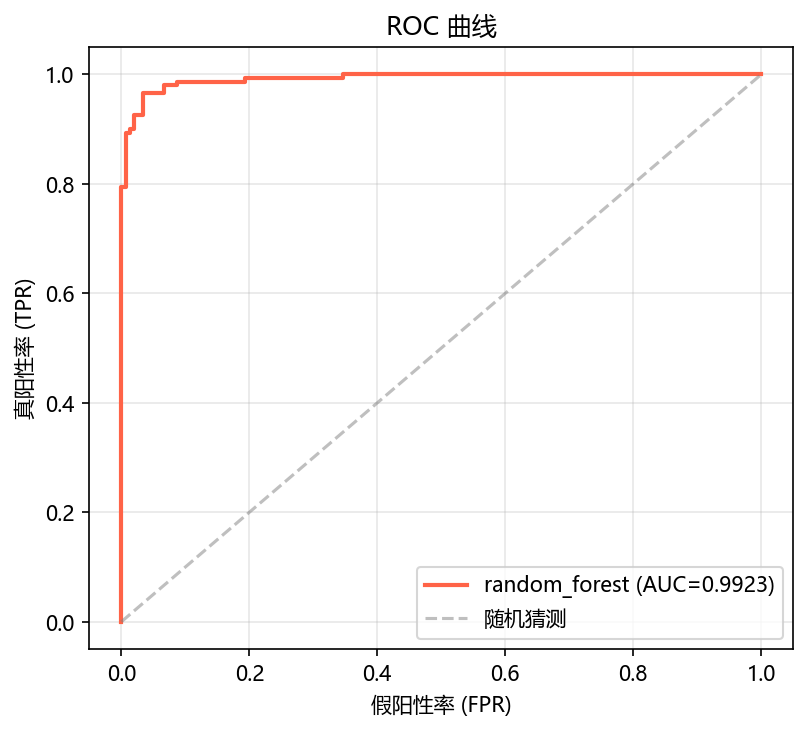

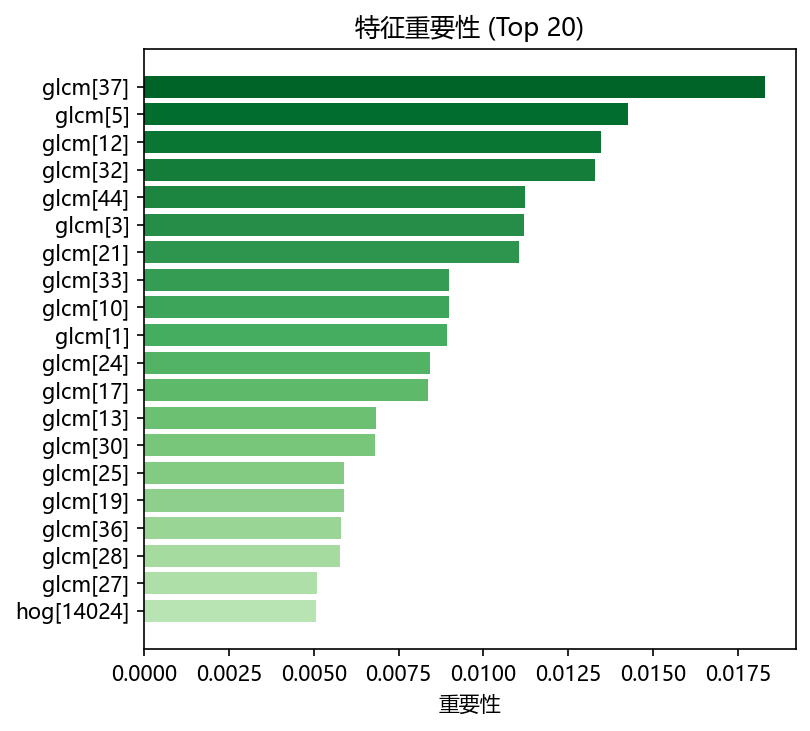

### 4.4 分析

随机森林以极低的训练成本（6.8 s）换来 AUC 最高（0.9928）的**平滑概率输出**，非常适合作为「快速基线 + 概率打分」模型。其特征重要性清晰揭示了 GLCM 纹理特征的主导地位，为后续特征选择提供了依据。

## 五、方法三 · XGBoost

### 5.1 原理

XGBoost 走的是 **Boosting（梯度提升）** 路线，与随机森林的 Bagging 形成对照：每一棵新树**拟合前面所有树的残差**（负梯度），逐步降低偏差。

- **二阶泰勒展开**：用一阶+二阶导数近似损失，收敛更快、更稳定（相比只用一阶导的传统 GBDT）。
- **正则化项** $\Omega = \gamma\cdot(叶子数) + \tfrac12\lambda\sum w_j^2$：显式控制模型复杂度，抑制过拟合。
- **融合 Bagging**：本项目 `subsample=0.8`，每轮只用 80% 数据训练单棵树，把 Bagging 的方差降低思想也融入了 Boosting。

### 5.2 关键超参与代码

| 参数 | 搜索网格 | **最优值** |
|------|----------|:--:|
| `n_estimators` | [50, 100, 200] | **50** |
| `max_depth` | [3, 6, 9] | **6** |
| `learning_rate` | [0.01, 0.1, 0.3] | **0.3** |
| `subsample` | [0.8, 1.0] | **0.8** |

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# —— 候选超参网格 ——
param_grid = {
    'n_estimators': [50, 100, 200],     # 提升轮数(树数)：Boosting 中需与 learning_rate 配合；少树+大步长可更快收敛
    'max_depth': [3, 6, 9],             # 每棵树深度：Boosting 用浅树(3~9)降偏差，6 为本任务最优
    'learning_rate': [0.01, 0.1, 0.3],  # 学习率(步长/shrinkage)：每棵树贡献的缩放系数，小值稳健慢、大值快但易跳过最优
    'subsample': [0.8, 1.0],            # 每棵树训练时的行采样比例：0.8 引入样本扰动，把 Bagging 思想融入 Boosting，降方差防过拟合
}
# 基学习器：verbosity=0 关闭训练日志，n_jobs=-1 并行
base_model = XGBClassifier(random_state=42, n_jobs=-1, verbosity=0)

grid = GridSearchCV(
    base_model, param_grid,
    cv=3,            # 3 折交叉验证
    scoring='f1',    # 以 F1 选优
    n_jobs=-1,       # 并行搜索
)
grid.fit(X_train, y_train)

# —— 用最优超参训练最终 XGBoost ——
best_xgb = XGBClassifier(
    n_estimators=50,                  # 仅 50 棵树：配合大学习率 0.3 即达最优，更多树反而过拟合
    max_depth=6,                      # 深度 6：Boosting 中等深度，兼顾表达能力与防过拟合
    learning_rate=0.3,                # 较大步长：50 棵树即可收敛，训练虽快但全数据仍耗时 165s(单线程分裂成本高)
    subsample=0.8,                    # 每棵树用 80% 样本：融合 Bagging 降方差
    colsample_bytree=1.0,             # 每棵树用全部特征(默认)；此处特征已充分，无需列采样
    objective='binary:logistic',      # 二分类 + logistic 输出概率：可绘 ROC/PR，并配合正则化项优化
    reg_alpha=0,                      # L1 正则权重(默认0)：叶子权重的 L1 惩罚，此处未启用
    reg_lambda=1,                     # L2 正则权重(默认1)：叶子权重 L2 惩罚，XGBoost 默认即带轻度正则
    random_state=42,                  # 固定 subsample/列采样随机性
    n_jobs=-1,                        # 并行
    verbosity=0,                      # 关闭日志
).fit(X_train, y_train)

### 5.3 实验结果

全数据（40,000 张）下的 XGBoost 结果 —— **四种方法中 F1 最高**：

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | **0.9715** | 训练阶段估计，最高 |
| **Test F1** | **0.9497** ⭐ | **四种方法中最高** |
| Test ROC-AUC | 0.9816 | 低于 RF（受 boosting 阶梯式概率影响） |
| **训练耗时** | **165.2 s** | 四种方法中**最慢**（约 RF 的 24 倍） |

下图为 2000 张子采样下的 XGBoost 诊断图（来源 `outputs/combo_verify/M05_*`）：

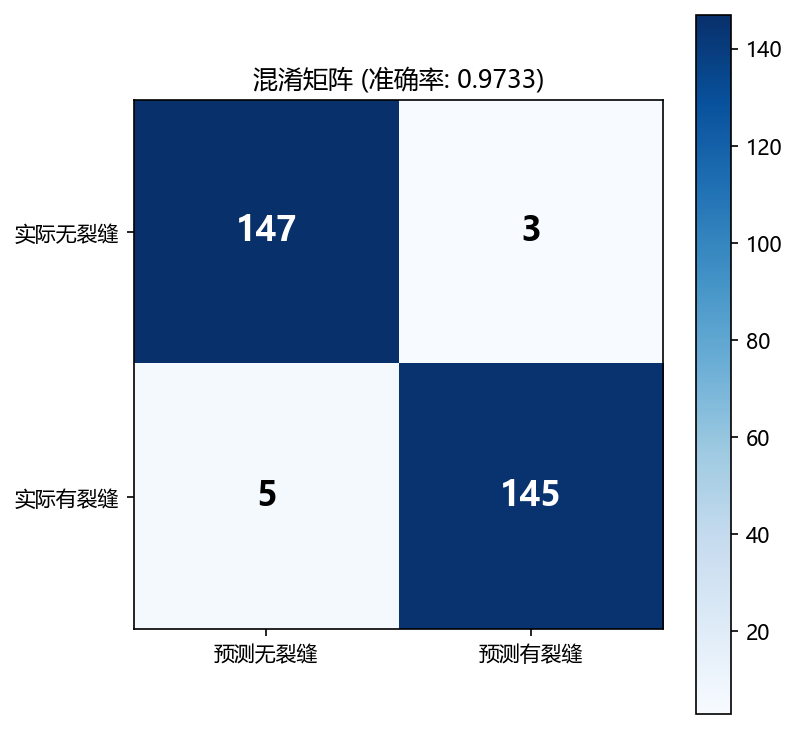

> （混淆矩阵四格含义见 3.3 节解读；XGBoost 的漏检 FN 与误报 FP 均明显少于决策树。）

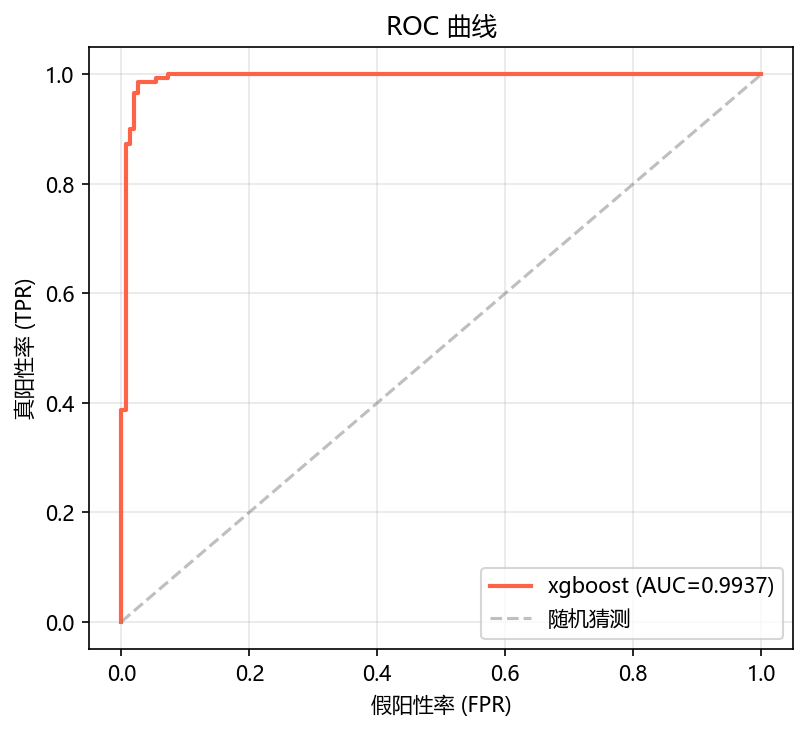

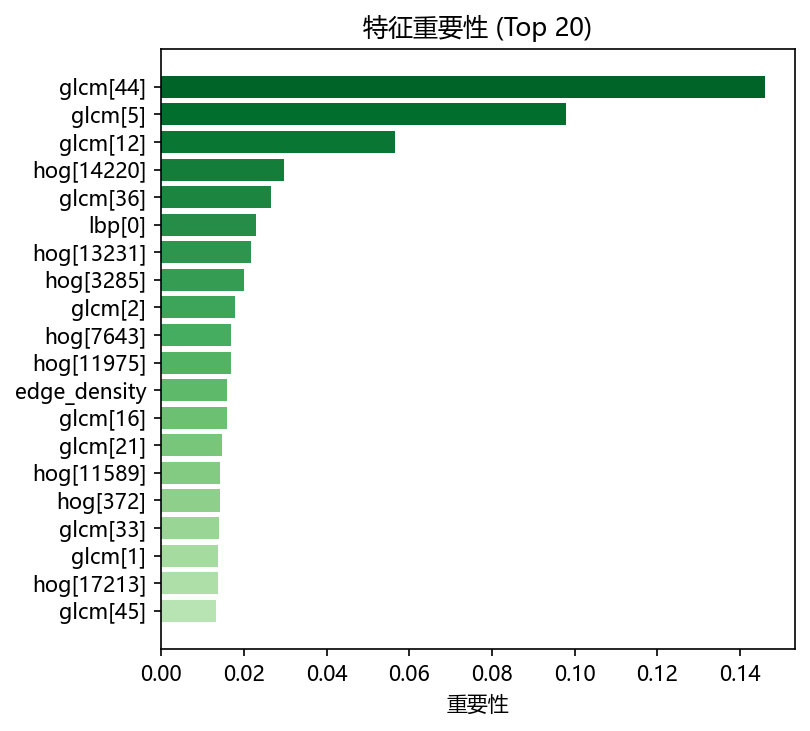

### 5.4 分析

XGBoost 在 F1 上夺冠（0.9497），其特征重要性图清晰地表明 **GLCM 纹理特征在 Top-20 中占约 50%、HOG 占约 40%**，LBP 与边缘密度各仅 1 个，印证了「裂纹识别本质是纹理分类」。但其训练耗时高达 165.2 s，是 LightGBM 的近 1.7 倍，性价比不如后者。

## 六、方法四 · LightGBM

### 6.1 原理

LightGBM（微软开源）在 XGBoost 的梯度提升框架上做了**工程优化**，核心两点：

- **直方图算法（Histogram）**：把连续特征离散化为若干 bin，分裂搜索从 $O(n\cdot features)$ 降为 $O(bins\cdot features)$，大幅加速。
- **Leaf-wise 生长策略**：不同于 XGBoost 的 Level-wise（层序生长），LightGBM 总是选择当前增益最大的叶子继续分裂，在同等叶子数下能学到更深的结构；但需用 `num_leaves` 直接控制模型复杂度以防过拟合。

### 6.2 关键超参与代码

| 参数 | 搜索网格 | **最优值** |
|------|----------|:--:|
| `n_estimators` | [50, 100, 200] | **100** |
| `max_depth` | [3, 6, 9] | **6** |
| `num_leaves` | [31, 63, 127] | **31** |
| `learning_rate` | [0.01, 0.1, 0.3] | **0.1** |

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# —— 候选超参网格 ——
param_grid = {
    'n_estimators': [50, 100, 200],      # 提升轮数：与 learning_rate 配合；100 轮收敛
    'max_depth': [3, 6, 9],              # 树最大深度：LightGBM 主要用 num_leaves 控复杂度，max_depth 作为额外上限
    'num_leaves': [31, 63, 127],         # 叶子数：LightGBM 的核心复杂度控制参数(Leaf-wise 策略)，必须 ≤2^max_depth；31 为默认且最优
    'learning_rate': [0.01, 0.1, 0.3],   # 学习率：0.1 兼顾收敛速度与稳定性
}
# 基学习器：verbose=-1 完全静默
base_model = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

grid = GridSearchCV(
    base_model, param_grid,
    cv=3,            # 3 折交叉验证
    scoring='f1',    # 以 F1 选优
    n_jobs=-1,       # 并行搜索
)
grid.fit(X_train, y_train)

# —— 用最优超参训练最终 LightGBM ——
best_lgbm = LGBMClassifier(
    n_estimators=100,                # 100 棵树：比 XGBoost 的 50 多，因学习率更小(0.1)需要更多轮
    max_depth=6,                     # 深度上限 6：与 num_leaves 协同防止 Leaf-wise 长出过深的单分支
    num_leaves=31,                   # 31 个叶子：Leaf-wise 策略下直接决定模型容量；31≤2^6=64 合理，是默认值也是最优
    learning_rate=0.1,               # 步长 0.1：比 XGBoost 的 0.3 小，故需更多树，但每轮更稳
    objective='binary',              # 二分类任务
    boosting_type='gbdt',            # 传统梯度提升决策树(默认)：直方图算法加速分裂搜索
    subsample=1.0,                   # 行采样(默认1.0，GOSS 除外)；LightGBM 直方图已足够高效，未额外引入行采样
    random_state=42,                 # 固定随机性
    n_jobs=-1,                       # 并行
    verbose=-1,                      # 静默
).fit(X_train, y_train)

### 6.3 实验结果

全数据（40,000 张）下的 LightGBM 结果：

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | **0.9738** | 训练阶段估计，最高 |
| **Test F1** | **0.9438** | 与随机森林并列，略低于 XGBoost |
| Test ROC-AUC | 0.9860 | — |
| **训练耗时** | **96.0 s** | 仅为 XGBoost 的 **58%**，性价比突出 |

下图为 2000 张子采样下的 LightGBM 诊断图（来源 `outputs/combo_verify/M06_*`）：

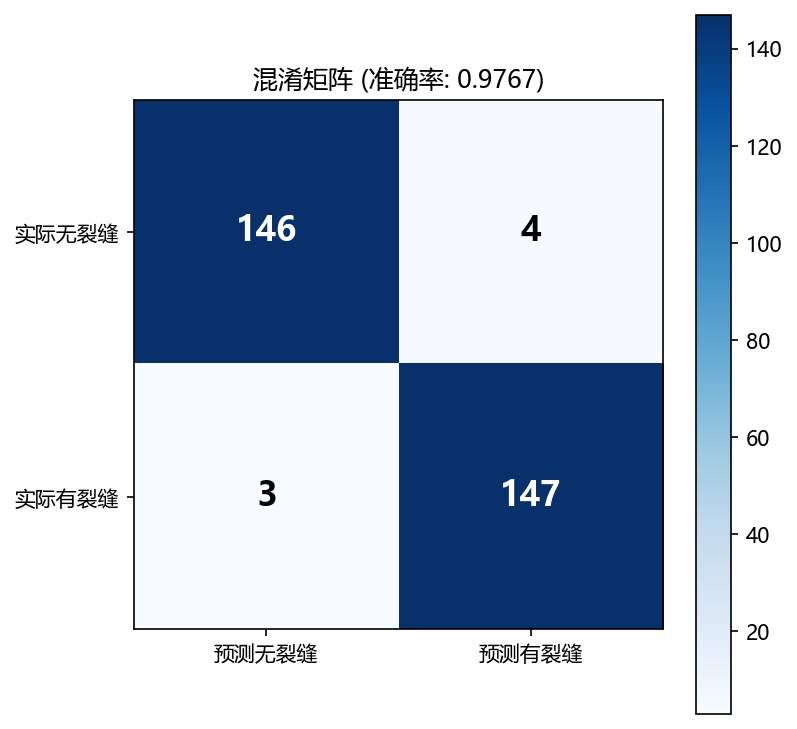

> （混淆矩阵四格含义见 3.3 节解读；LightGBM 的检出率（右下 TP）与决策树相比显著提升。）

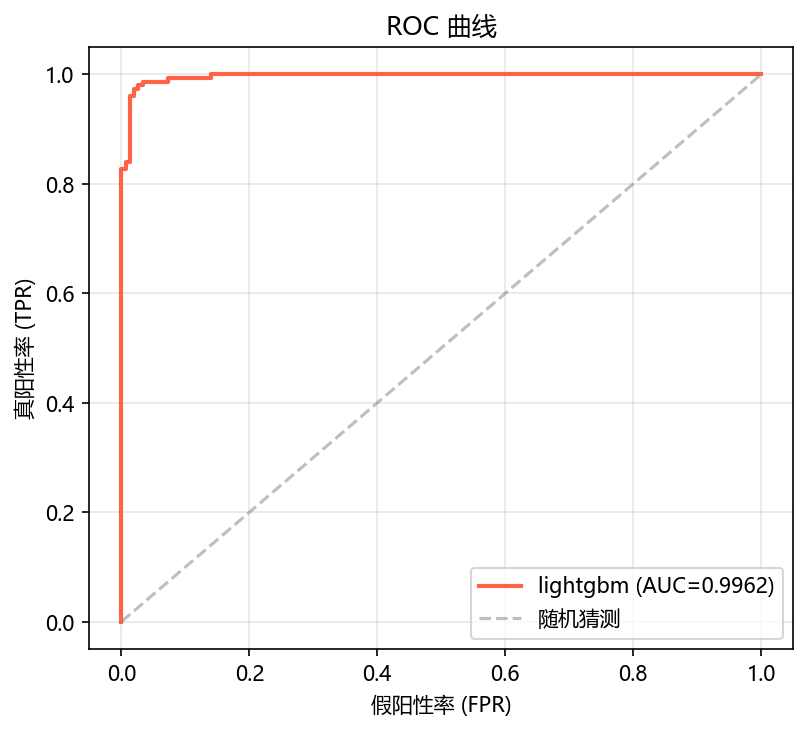

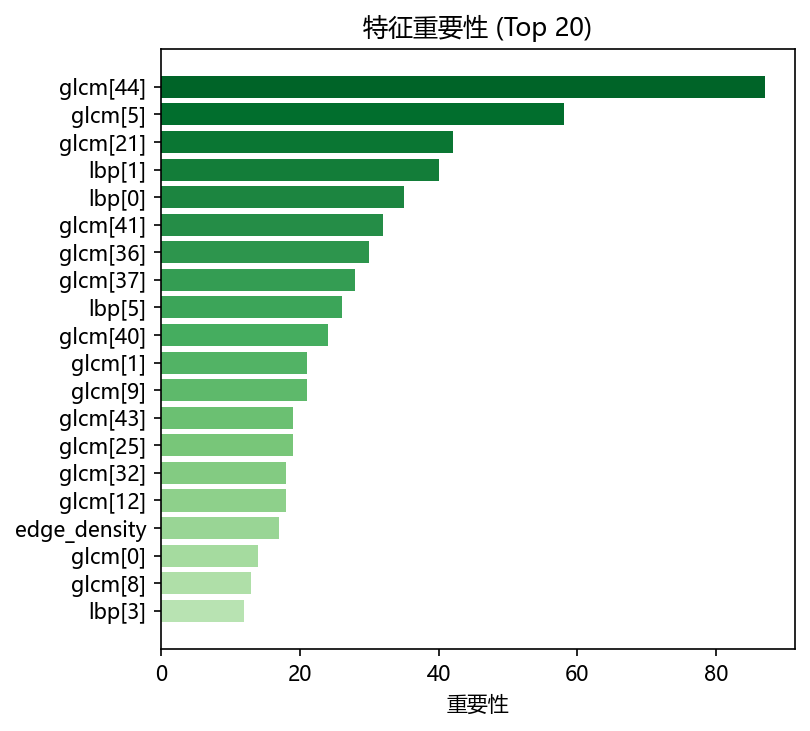

### 6.4 分析

**一、对 XGBoost（同为 Boosting）：性价比明显更高**

LightGBM 用更少的训练时间（96 s vs 165.2 s，约为后者的 **58%**）取得了与 XGBoost 几乎相当的效果（F1 0.9438 vs 0.9497，差距仅 0.6 pp）。两者同为梯度提升，但 LightGBM 的直方图算法把单次分裂搜索的复杂度从 $O(n\cdot features)$ 降到 $O(bins\cdot features)$，在同等模型结构下训练更快、内存更省。因此在「追求 Boosting 精度但算力有限」时，LightGBM 是 XGBoost 的高效替代。

**二、对随机森林（F1 同为 0.9438，RF 仅 6.8 s）：LightGBM 仍有不可替代价值**

一个自然的疑问是：**全数据下 LightGBM 与随机森林 F1 完全相同（0.9438），而随机森林训练快 14 倍（6.8 s），LightGBM 岂不无用？** 深入对比可见 LightGBM 在以下维度仍有真实优势：

| 维度 | LightGBM | 随机森林 | LightGBM 优势点 |
|------|:--:|:--:|------|
| **小样本表现（2000 子采样）** | **F1=0.9767** | F1=0.9632 | 子采样下 LightGBM 反超 RF 1.4 pp——数据量减小时 Boosting 的偏差降低能力更突出 |
| **CV F1（训练集内估计）** | **0.9738** | 0.9495 | 训练阶段交叉验证 F1 高 2.4 pp，泛化上限更高 |
| **可调参深度** | learning_rate / num_leaves 等精细旋钮 | 主要靠 n_estimators | LightGBM 的学习率、叶子数等超参对偏差-方差权衡控制更精细，调优空间更大 |
| **大数据可扩展性** | 直方图 + Leaf-wise，内存占用低 | 树多则内存线性增长 | 数据规模 / 特征维度进一步增大时，LightGBM 优势会持续放大 |
| **判别方向** | 降低**偏差**（拟合残差） | 降低**方差**（多树投票） | 任务不同取舍不同——本任务两路殊途同归到 0.9438 |

**核心结论**：在全数据 + 强特征（GLCM 主导、接近线性可分）这一特定场景下，RF 与 LightGBM 恰好「**殊途同归**」到同一 F1。RF 以 6.8 s 的极低训练成本取胜，而 LightGBM 的价值体现在**更强的泛化上限（CV F1 0.9738）与小样本稳定性（子采样 0.9767 第一）**，以及面对更大数据 / 更高维特征时的可扩展性。换言之：**RF 是「当前场景的效率之王」，LightGBM 是「跨场景的稳健之选」**。

## 七、四模型横向对比 ⭐

下面是项目预先生成的总览对比图（`F5_树模型与集成对比`），汇总了四种方法在全数据下的核心指标：

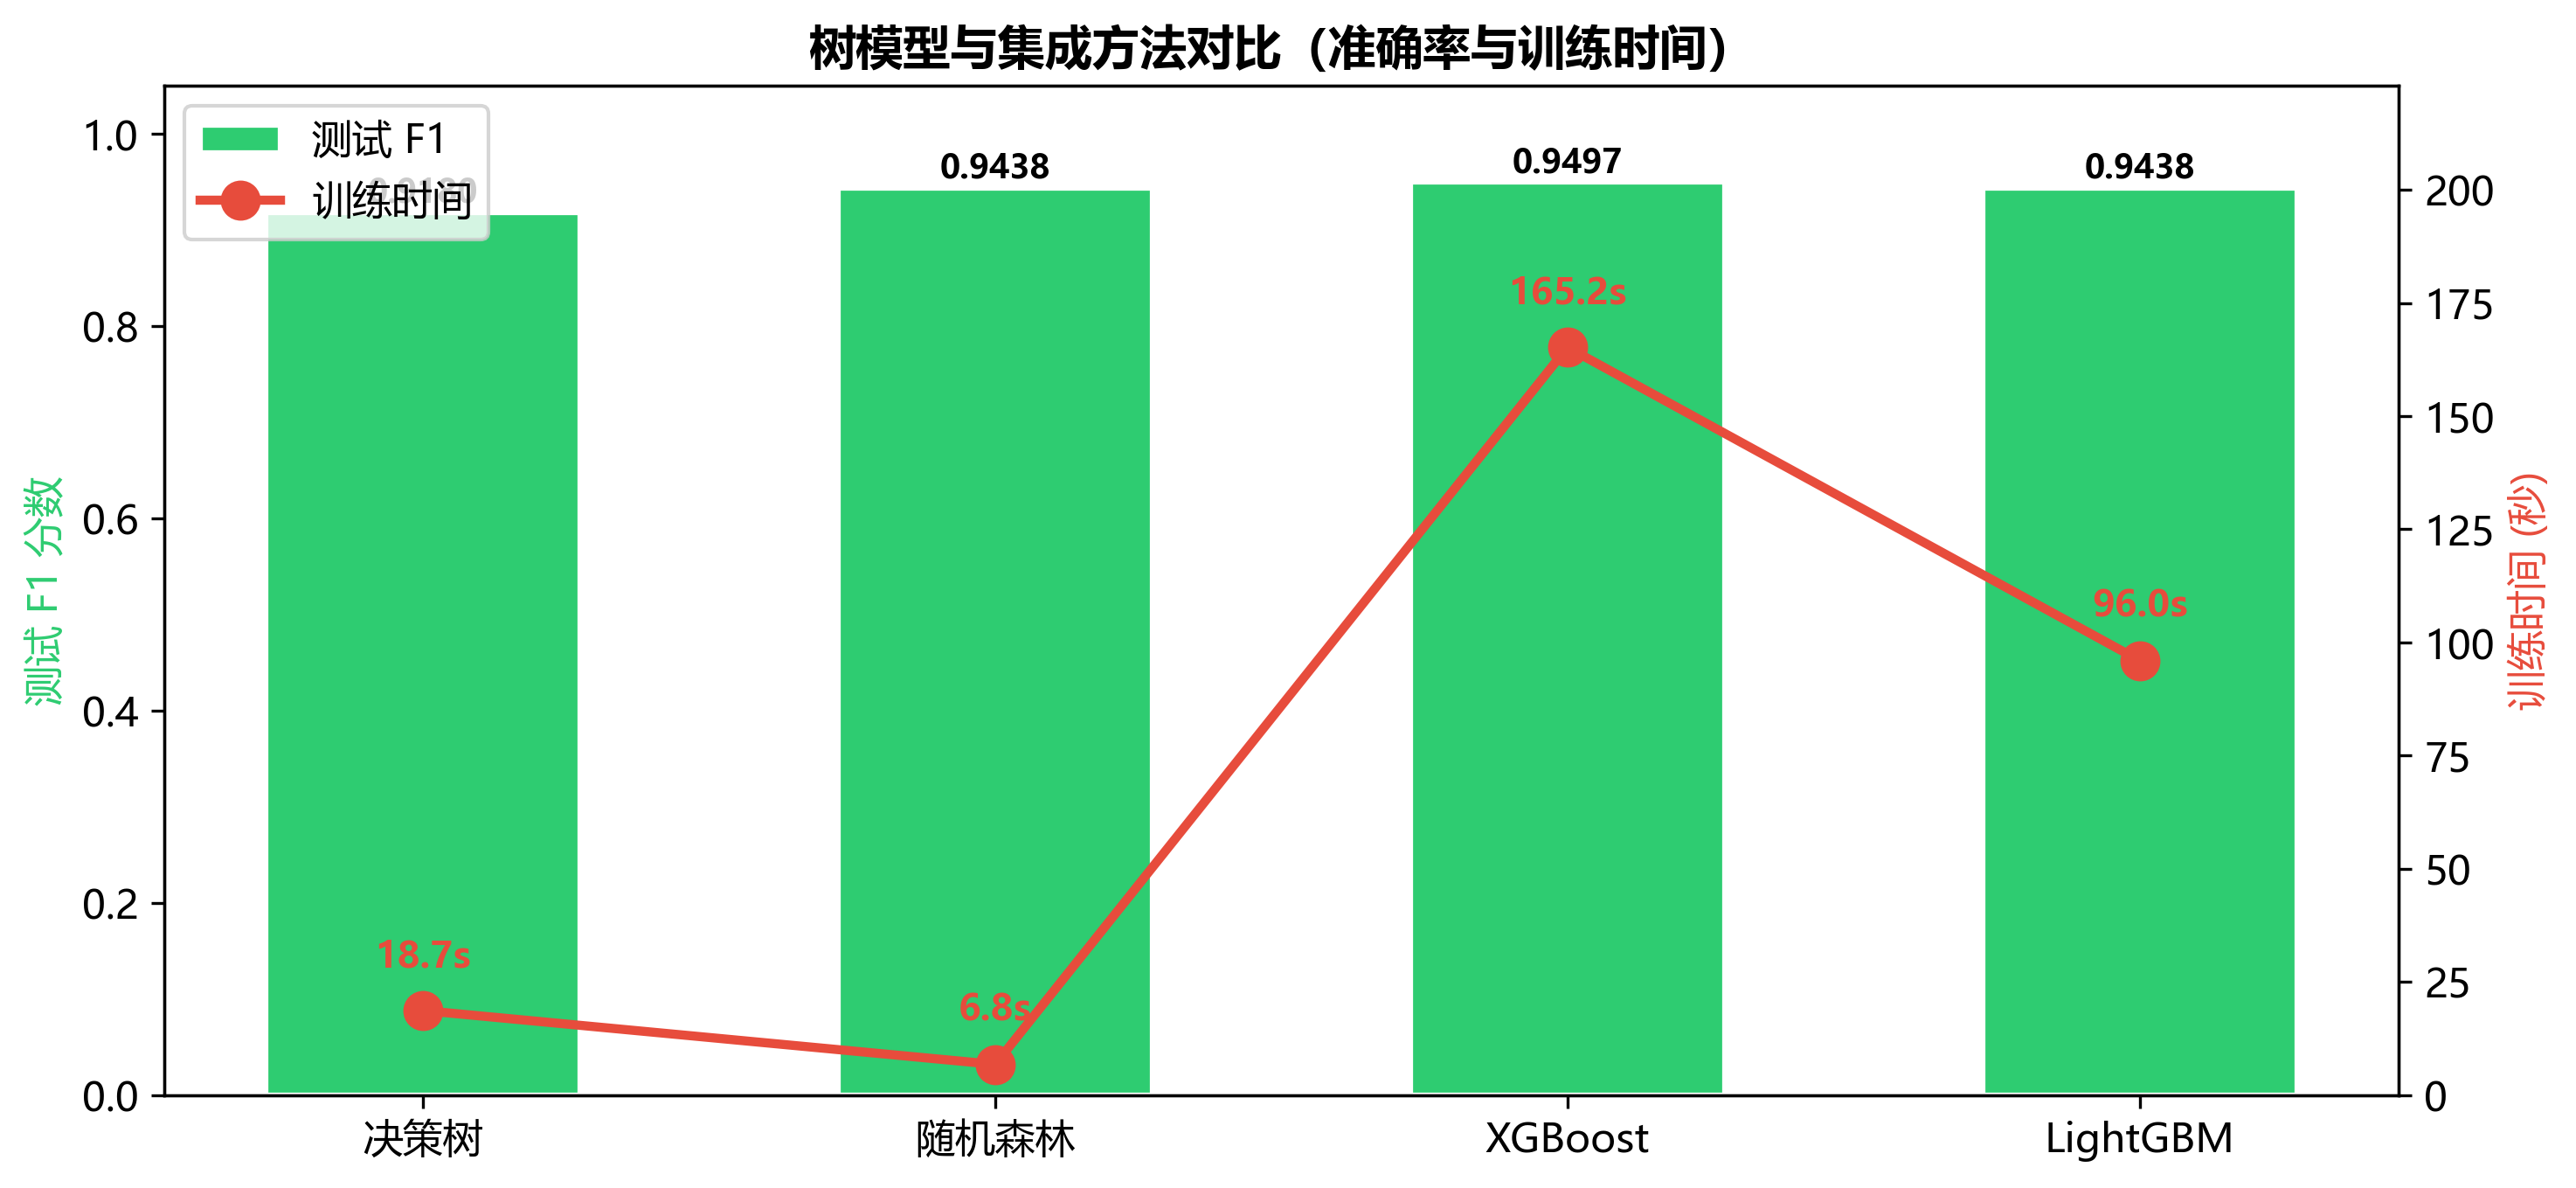

### 7.1 全数据（40,000 张）综合对比表

下表数据直接来自 `outputs/results/traditional_comparison.csv`：

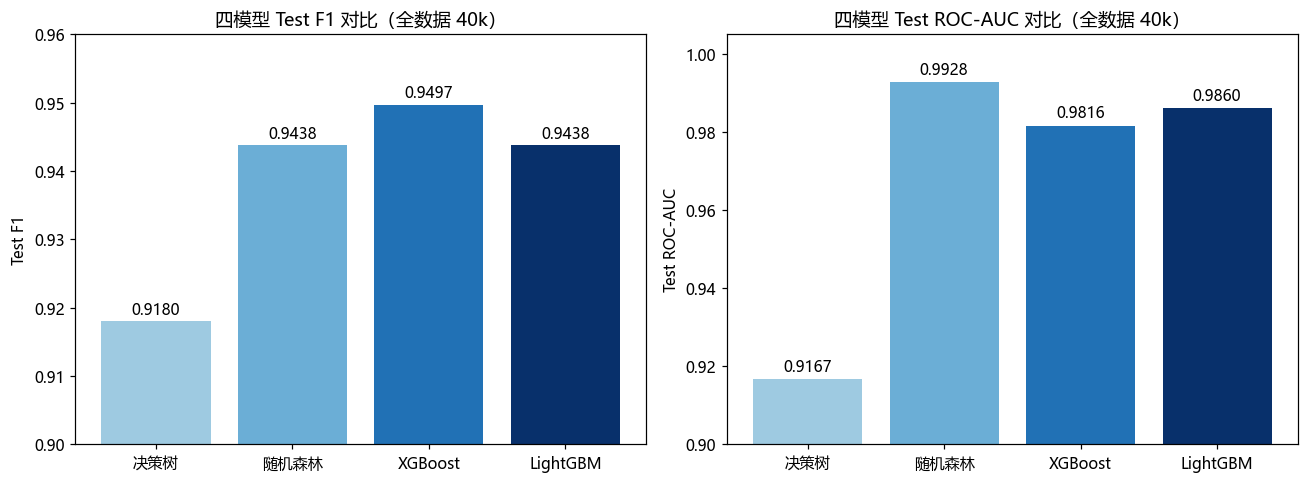

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取全数据实验结果表（model, cv_f1, test_f1, test_auc, time_s）
df = pd.read_csv("../outputs/results/traditional_comparison.csv")
# 按固定顺序排列四种树模型，便于横向对比
order = ["decision_tree", "random_forest", "xgboost", "lightgbm"]
df = df.set_index("model").loc[order].reset_index()
# 英文模型名映射为中文标签，提升图表可读性
labels = {"decision_tree": "决策树", "random_forest": "随机森林",
          "xgboost": "XGBoost", "lightgbm": "LightGBM"}
df["label"] = df["model"].map(labels)

# 创建 1×2 子图：左 F1，右 AUC；figsize 控制整图尺寸(宽12英寸×高4.5英寸)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# 同色系蓝色渐变：颜色由浅到深，视觉上暗示性能递进
colors = ["#9ecae1", "#6baed6", "#2171b5", "#08306b"]

# —— 左图：Test F1 柱状图 ——
bars = axes[0].bar(df["label"], df["test_f1"], color=colors)
axes[0].set_title("四模型 Test F1 对比（全数据 40k）", fontsize=12)
axes[0].set_ylim(0.90, 0.96)           # y 轴起点设为 0.90 而非 0，放大模型间差异便于观察
axes[0].set_ylabel("Test F1")
for b, v in zip(bars, df["test_f1"]):  # 在每根柱顶标注精确数值
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.001, f"{v:.4f}",
                 ha="center", fontsize=10)

# —— 右图：Test ROC-AUC 柱状图 ——
bars = axes[1].bar(df["label"], df["test_auc"], color=colors)
axes[1].set_title("四模型 Test ROC-AUC 对比（全数据 40k）", fontsize=12)
axes[1].set_ylim(0.90, 1.005)
axes[1].set_ylabel("Test ROC-AUC")
for b, v in zip(bars, df["test_auc"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
                 ha="center", fontsize=10)

plt.tight_layout()   # 自动调整子图间距，避免标签重叠

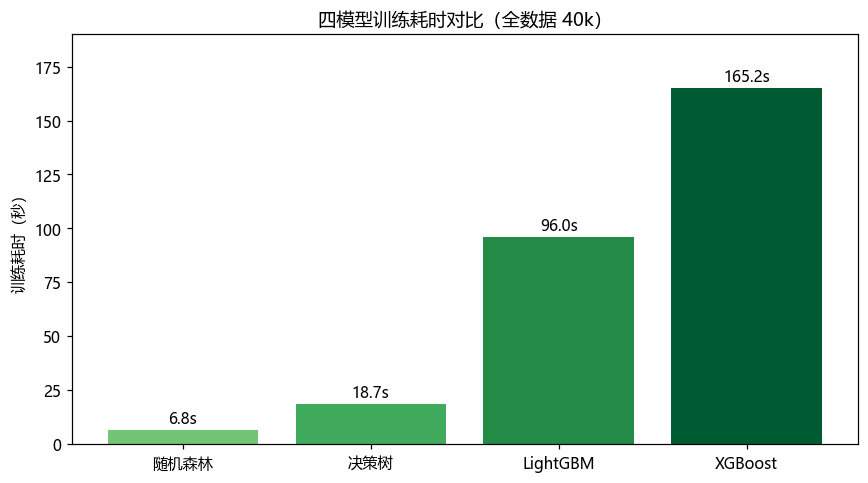

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/results/traditional_comparison.csv")
# 按训练耗时升序排列，柱子由低到高，直观呈现速度差异
order = ["random_forest", "decision_tree", "lightgbm", "xgboost"]  # 按耗时升序
df = df.set_index("model").loc[order].reset_index()
labels = {"decision_tree": "决策树", "random_forest": "随机森林",
          "xgboost": "XGBoost", "lightgbm": "LightGBM"}
df["label"] = df["model"].map(labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
# 绿色系渐变：浅→深对应耗时少→多
colors = ["#74c476", "#41ab5d", "#238b45", "#005a32"]
bars = ax.bar(df["label"], df["time_s"], color=colors)
ax.set_title("四模型训练耗时对比（全数据 40k）", fontsize=12)
ax.set_ylabel("训练耗时（秒）")
for b, v in zip(bars, df["time_s"]):
    ax.text(b.get_x() + b.get_width()/2, v + 3, f"{v:.1f}s",
            ha="center", fontsize=10)
ax.set_ylim(0, max(df["time_s"]) * 1.15)   # 顶部留 15% 空白，给数值标签留位置
plt.tight_layout()

### 7.2 全数据 vs 2000 子采样 · 双口径对照

项目同时维护了两套实验口径：**全数据 40k**（稳健但耗时）与 **2000 子采样**（快速、用于组合验证）。下表对照两种口径下的 F1，来源 `all_results.json`：

| 模型 | 全数据 40k F1 | 2000 子采样 F1 | 子采样耗时 |
|------|:--:|:--:|:--:|
| 决策树 | 0.9180 | 0.9369 | 6.7 s |
| 随机森林 | 0.9438 | 0.9632 | 29.3 s |
| XGBoost | **0.9497** | 0.9732 | 16.1 s |
| LightGBM | 0.9438 | **0.9767** | 14.9 s |

> **观察**：子采样下各模型 F1 普遍更高（数据量小、更易拟合），且 **LightGBM 在子采样下以 0.9767 排名第一**；但全数据下 XGBoost 反超（0.9497 vs 0.9438），说明在大样本下 XGBoost 的二阶优化优势更明显。这也提醒我们：**结论需结合数据规模解读，不能只看单一口径。**

### 7.3 性价比分析

下图直观展示「精度 vs 训练耗时」的权衡（全数据口径）：

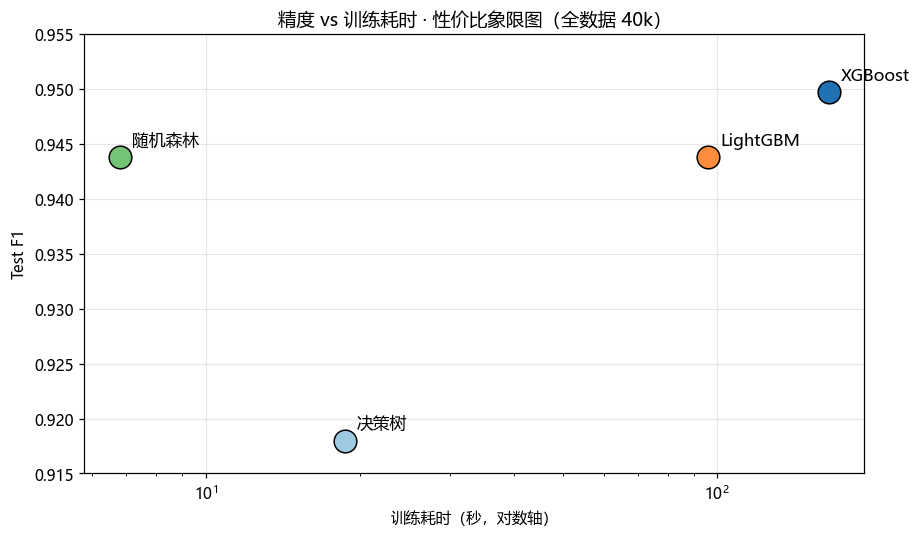

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/results/traditional_comparison.csv")
keep = ["decision_tree", "random_forest", "xgboost", "lightgbm"]
df = df.set_index("model").loc[keep].reset_index()
labels = {"decision_tree": "决策树", "random_forest": "随机森林",
          "xgboost": "XGBoost", "lightgbm": "LightGBM"}
df["label"] = df["model"].map(labels)

fig, ax = plt.subplots(figsize=(8.5, 5))
# 每个模型一种颜色，便于在散点图中区分
color_map = {"decision_tree": "#9ecae1", "random_forest": "#74c476",
             "xgboost": "#2171b5", "lightgbm": "#fd8d3c"}
# 逐模型绘制散点：x=训练耗时(秒)，y=Test F1，构成"精度 vs 成本"权衡图
for _, r in df.iterrows():
    ax.scatter(r["time_s"], r["test_f1"], s=220,      # s=220 控制点的大小，便于标注
               color=color_map[r["model"]], edgecolor="black", zorder=3)  # zorder=3 使点在网格之上
    # 在点旁偏移(8,8)像素处标注模型中文名
    ax.annotate(r["label"], (r["time_s"], r["test_f1"]),
                xytext=(8, 8), textcoords="offset points", fontsize=11)

ax.set_xlabel("训练耗时（秒，对数轴）")
ax.set_ylabel("Test F1")
ax.set_xscale("log")            # x 轴用对数刻度：RF(6.8s)到XGBoost(165s)跨24倍，对数轴才能同时清晰展示
ax.set_title("精度 vs 训练耗时 · 性价比象限图（全数据 40k）", fontsize=12)
ax.set_ylim(0.915, 0.955)       # y 轴放大精度区间，凸显模型差异
ax.grid(True, alpha=0.3)        # alpha=0.3 半透明网格，辅助读数不抢眼
plt.tight_layout()

**象限解读**：

- **左上（高精度、低耗时）= 理想区**：随机森林（6.8 s / F1=0.9438）位于此区，综合最优。
- **右上（高精度、高耗时）**：XGBoost（165 s / F1=0.9497）精度最高，但代价大。
- **右中（中精度、中耗时）**：LightGBM（96 s / F1=0.9438）是 XGBoost 的**高效替代**——耗时仅为其 58%，精度仅低 0.6 pp。
- **左下**：决策树（18.7 s / F1=0.9180）作为基线。

> **结论**：追求精度选 XGBoost；想要 Boosting 精度但更省时选 LightGBM（XGBoost 的高效替代，跨场景稳健）；追求速度 + 平滑概率选随机森林（当前场景效率之王）；决策树仅作基线。

## 八、结论与启示

### 8.1 方法演进路径总结

四种方法构成了一条清晰的集成学习升级路径：

| 阶段 | 方法 | 核心思想 | 解决的问题 | 全数据 F1 |
|------|------|----------|-----------|:--:|
| 单模型 | **决策树** | 递归划分特征空间 | 可解释性 | 0.9180 |
| ↓ Bagging | **随机森林** | 100 棵树投票、降方差 | 过拟合、稳健性 | 0.9438 |
| ↓ Boosting | **XGBoost** | 拟合残差 + 二阶导 + 正则化 | 降低偏差 | **0.9497** |
| ↓ 工程优化 | **LightGBM** | 直方图 + Leaf-wise | 训练效率 | 0.9438 |

### 8.2 核心结论

1. **最高精度 = XGBoost（F1=0.9497）**：二阶泰勒优化 + 正则化让它在全数据下夺冠。
2. **对 Boosting 阵营的最佳性价比 = LightGBM（F1=0.9438，96 s）**：训练耗时仅为 XGBoost 的 58%，精度差距仅 0.6 pp；且子采样下 F1=0.9767 居首、CV F1=0.9738 泛化上限更高，是跨场景的稳健之选。
3. **全场景效率之王 = 随机森林（F1=0.9438，6.8 s，AUC 最高 0.9928）**：在当前强特征 + 全数据场景下，RF 以 1/14 的训练成本达到与 LightGBM 相同的 F1、且概率输出最平滑，是当前场景的效率首选。
4. **Bagging（RF）vs Boosting（XGB/LGBM）的本质差异**：前者通过并行投票**降方差**、用深树；后者通过串行拟合残差**降偏差**、用浅树。本任务两路殊途同归到 F1≈0.9438。
5. **树模型对特征尺度不敏感**：与 SVM / 逻辑回归不同，决策树及其集成**无需标准化**，省去一步预处理。
6. **AUC 维度的反直觉现象**：随机森林 AUC 最高（0.9928），高于 XGBoost（0.9816）。原因是随机森林的投票平均天然产生平滑概率，而 boosting 的概率输出呈阶梯状——AUC 偏好平滑概率，故 RF 在此指标占优。

### 8.3 与项目其他方法的定位

本报告聚焦的四种树方法在项目整体方法谱系中的位置：

| 方法类别 | 代表 | 全数据 F1 | 角色 |
|---------|------|:--:|------|
| 基础监督 | 逻辑回归 / SVM / 朴素贝叶斯 | 0.908–0.9665 | 基线 |
| **树与集成（本报告）** | **DT / RF / XGBoost / LightGBM** | **0.918–0.9497** | **性价比之选** |
| 深度学习 | CNN + Focal Loss | **0.9980** | 全局最佳（端到端） |
| 无监督聚类 | K-Means / GMM / 层次 / 谱 | ARI≈0 | 失效（证明标签价值） |

> **最终定位**：CNN + Focal Loss（F1=0.9980）是全局最佳，但需要 GPU 与端到端训练；**树与集成方法在「可解释性 + 无需 GPU + 训练快」的综合维度上不可替代**，是工业部署中「性价比之选」的最佳候选。